In [ ]:
import pandas as pd
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, opinion_lexicon
import string
from nltk.stem import PorterStemmer
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import numpy as np
import networkx as nx
from collections import Counter
import warnings
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

warnings.filterwarnings('ignore')
nltk.download('punkt_tab')
df = pd.read_csv("PSTAT 134 Project/netflix_reviews.csv")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/anugrhatamang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/anugrhatamang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/anugrhatamang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [55]:
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')

In [56]:
df = df.drop(columns = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion'])
df.columns

Index(['content', 'score'], dtype='object')

In [57]:
# making a sample of 10000 entries from the dataset
sample, _ = train_test_split(df, train_size = 10000, stratify = df['score'], random_state = 42)
sample.reset_index(drop = True, inplace = True)
sample['score'].value_counts()

score
1    3930
5    3173
4    1084
3     946
2     867
Name: count, dtype: int64

In [58]:
len(sample)

10000

In [59]:
# droping null values, removing punctuation, and converting to lowercase
sample = sample.dropna()
sample['content'] = sample['content'].str.replace(r"[^A-Za-z\s]", "", regex=True).str.lower()

In [60]:
len(sample)

9998

In [61]:
# no more null values
sample.isna().sum()

content    0
score      0
dtype: int64

In [62]:
# making a new column which has a list of all words in that row's content column and then dropping the content column
sample['content_tokenized'] = sample['content'].apply(word_tokenize) 
sample = sample.drop(columns = ['content'])

In [63]:
# defining set of stopwords
stop_words = set(stopwords.words('english'))

# defining function to remove stop words
def remove_stop(review):
    filtered = [word for word in review if word not in stop_words]
    return filtered

In [64]:
# removing stop words from content_tokenized column
sample['content_tokenized'] = sample['content_tokenized'].apply(remove_stop)

In [65]:
# making another column in sample with the words from the cleaned content column as strings
def into_string(content):
    return " ".join(content)

sample['content_string'] = sample['content_tokenized'].apply(into_string)

In [66]:
# swapping order of columns for improved readablility
sample = sample[['content_tokenized', 'content_string', 'score']]

In [67]:
sample.head(10)

,content_tokenized,content_string,score
0,"[used, netflix, years, mainly, low, pricing, g...",used netflix years mainly low pricing good sel...,1
1,"[playing, anything, huawei, p, pro, everytime,...",playing anything huawei p pro everytime video ...,1
2,"[new, update, stupid, dad, lives, different, s...",new update stupid dad lives different state us...,2
3,"[nice, app]",nice app,5
4,"[dont, know, download, movie, become, slowi, n...",dont know download movie become slowi need res...,3
5,"[love, neftlix, love, watch, movies, tv, dead,...",love neftlix love watch movies tv dead fun wat...,5
6,[good],good,5
7,"[lets, take, im, using, x, profile, showing, p...",lets take im using x profile showing profile l...,5
8,"[still, semi, regularly, hands, logo, paying, ...",still semi regularly hands logo paying content...,1
9,"[app, open, oneplus, pro, stuck, netflix, load...",app open oneplus pro stuck netflix loading scr...,1


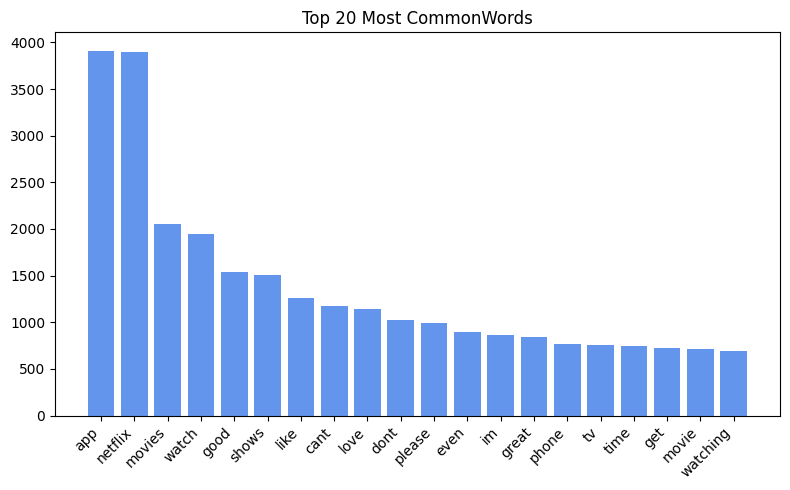

In [68]:
# bar chart for most common words
all_words = [w for tokens in sample['content_tokenized'] for w in tokens]
top_overall = Counter(all_words).most_common(20)

words, counts = zip(*top_overall)
plt.figure(figsize=(8, 5))
plt.bar(words, counts, color='cornflowerblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most CommonWords')
plt.tight_layout()
plt.show()

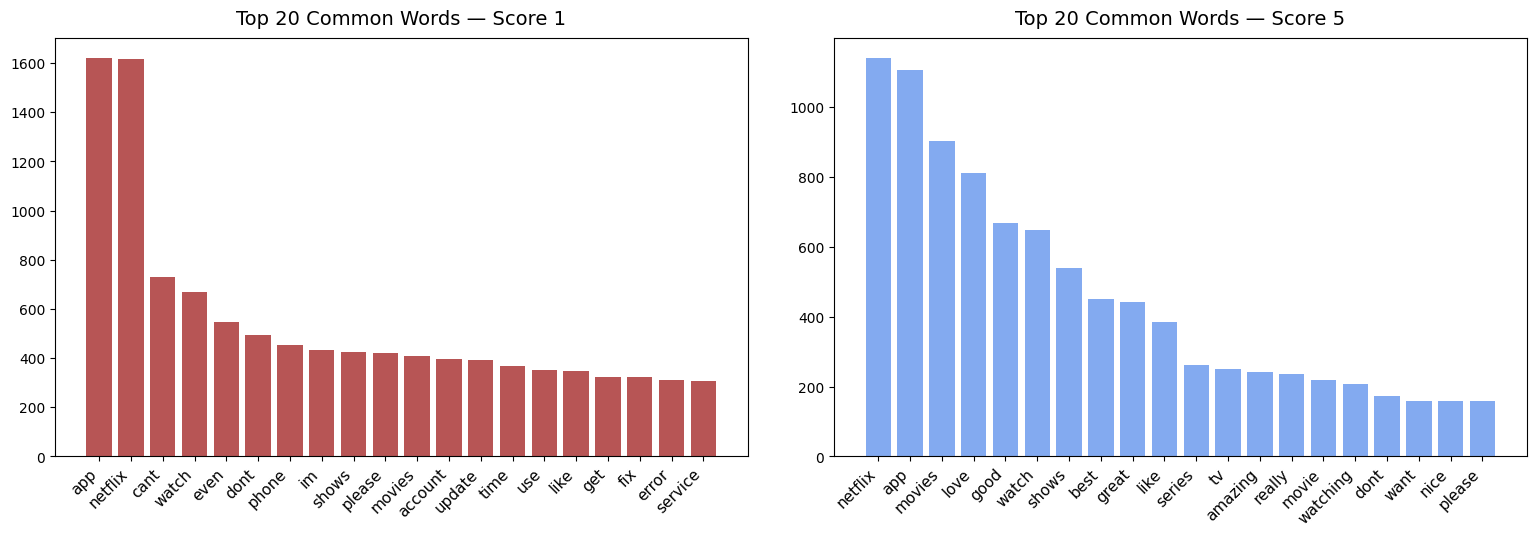

In [79]:
# bar chart for most common words of the highest and lowest scores
score_colors = {1: 'brown', 5: 'cornflowerblue'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, score in zip(axes, [1, 5]):
    words_score = [
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    ]
    top = Counter(words_score).most_common(20)
    w, c = zip(*top)
    ax.bar(w, c, color=score_colors[score], alpha=0.8)
    ax.set_title(f'Top 20 Common Words — Score {score}', fontsize=14, pad=10)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xticklabels(w, rotation=45, ha='right')
plt.tight_layout(pad=3.0)
plt.show()

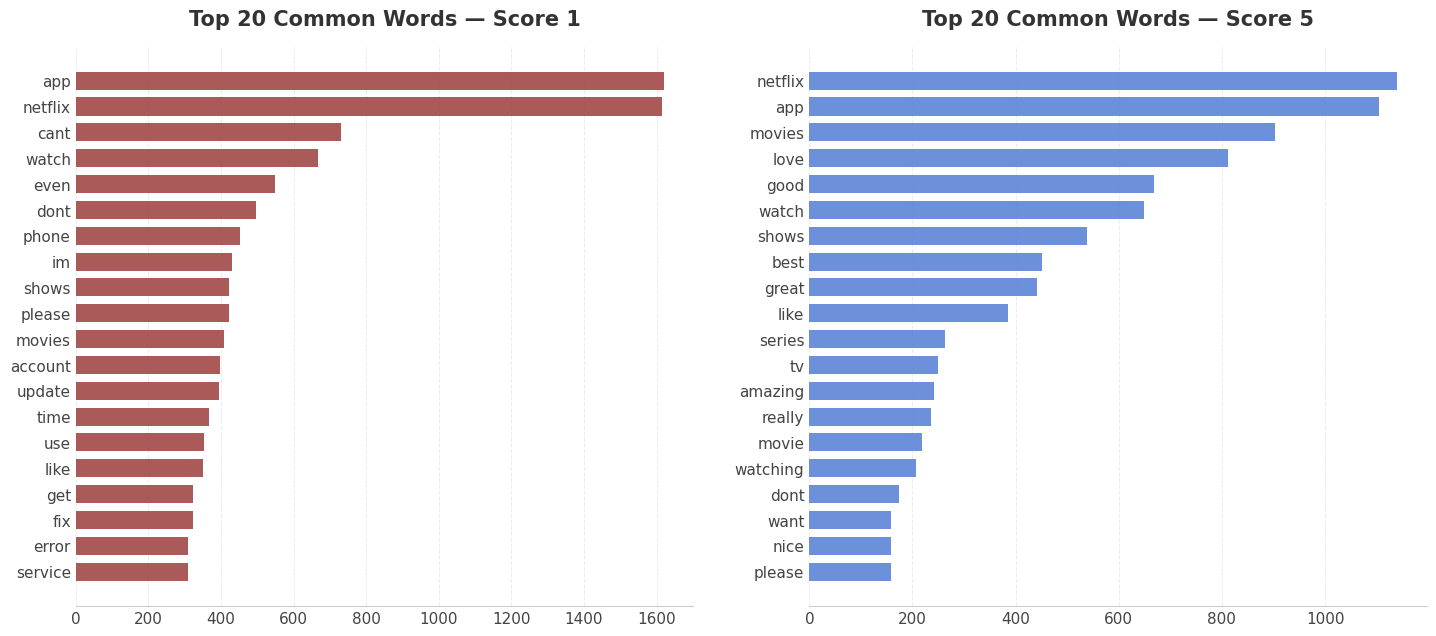

In [85]:
import matplotlib.pyplot as plt
from collections import Counter


fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

for ax, score in zip(axes, [1, 5]):
    words_score = [
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    ]
    # Keep it to top 20, but reverse it for barh so the highest count is at the top
    top = Counter(words_score).most_common(20)
    w, c = zip(*top)
    w, c = list(w)[::-1], list(c)[::-1] 
    
    # Draw horizontal bars
    ax.barh(w, c, color=score_colors[score], alpha=0.9, height=0.7)
    
    # Title formatting
    ax.set_title(f'Top 20 Common Words — Score {score}', fontsize=15, pad=15, weight='bold', color='#333333')
    
    # Clean up tick parameters
    ax.tick_params(axis='both', which='both', length=0, labelsize=11, colors='#444444')
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#E0E0E0')
    ax.set_axisbelow(True) # Ensures gridlines sit behind bars
    
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC') # Mute the bottom axis line
plt.tight_layout(pad=3.0)
plt.show()